# LEO Satellite Routing — Project Overview

**Paper:** *Mimicking Delay-Aware Routing in LEO Networks: A Random Forest Approach with Local-Only Features*  
**Author:** Nazanin Ansaripour · University of Rome Tor Vergata / University of Göttingen  
**Supervisor:** Prof. Ernestina Cianca

---

This notebook shows the key results and visualizations from the full pipeline.  
The complete source code is available upon request — contact via [LinkedIn](https://linkedin.com/in/nazanin-ansaripour) or open a GitHub issue.

---

## Pipeline overview

| Phase | What happens |
|---|---|
| 1–3 | Raw constellation data → cleaned topology (90 nodes, 574 links) |
| 4 | Diurnal Poisson traffic model — region-skewed toward European peak |
| 5 | Queue simulation under normal load |
| 6 | Feature engineering (11 features per candidate hop) |
| 7 | Congestion & stress scenario generation |
| 8–9 | Three-way routing comparison: DistanceOnly vs DelayAware vs ML-Agent |
| 10–11 | Supervised training, evaluation, statistical tests |


### Phase 1–2 — Constellation topology

90-node connected subgraph of a OneWeb-like 648-satellite constellation. Region-aware sampling keeps 37 European nodes, 40 North American, rest elsewhere — matching real demand patterns.

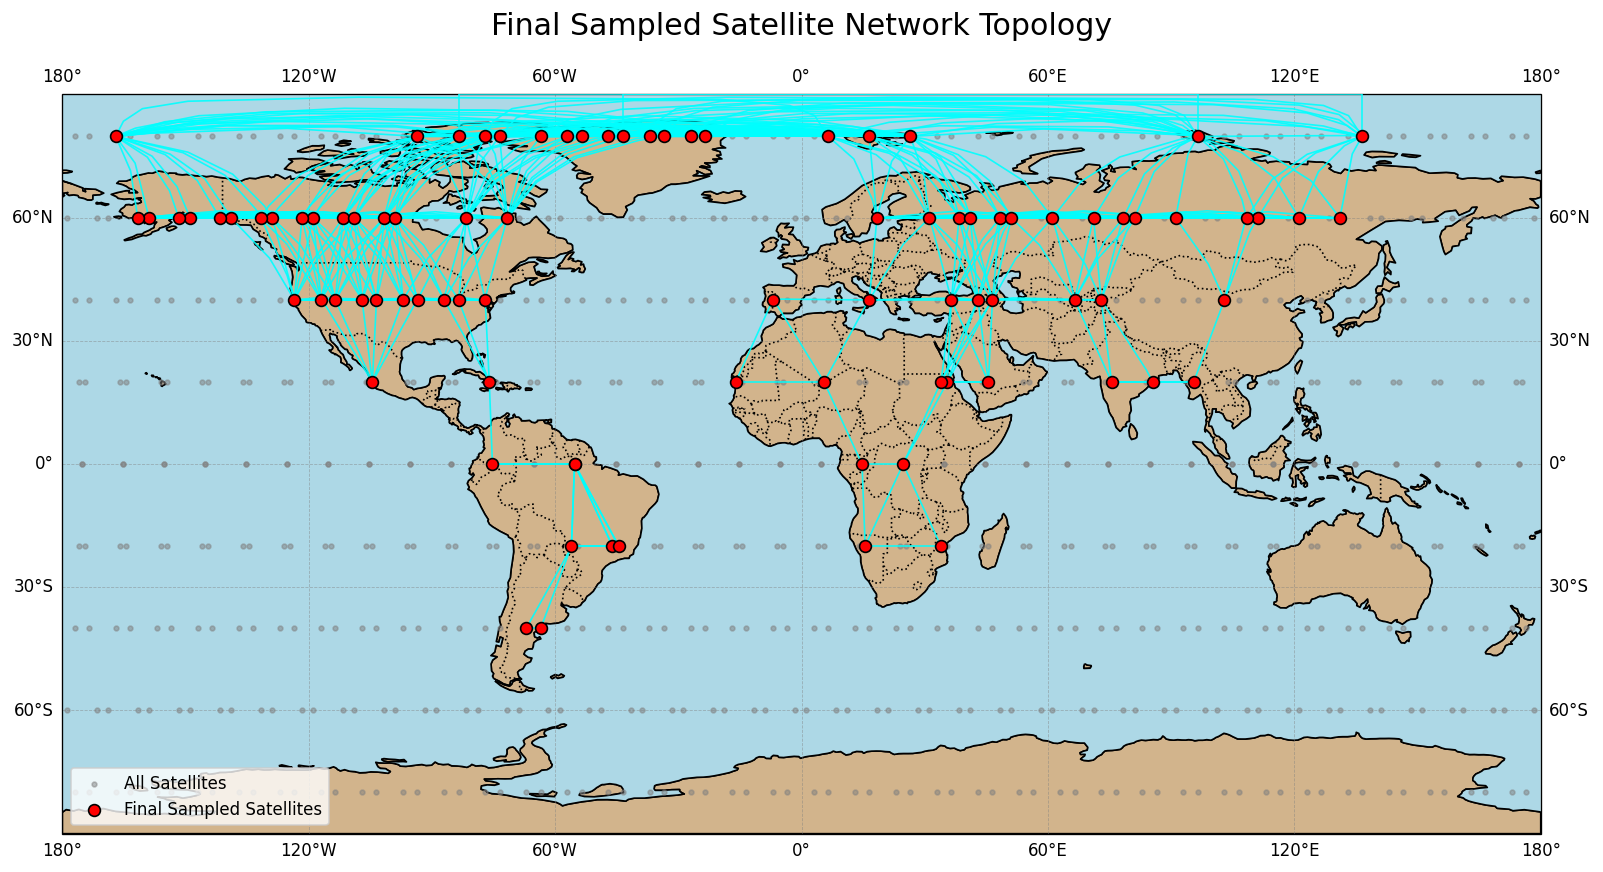


### Phase 4 — Traffic model: regional time series

Diurnal Poisson load. European nodes peak at λ ≈ 50 pkt/s during daytime. North American nodes at λ ≈ 25 pkt/s. The asymmetry creates realistic congestion hotspots in the European corridor.

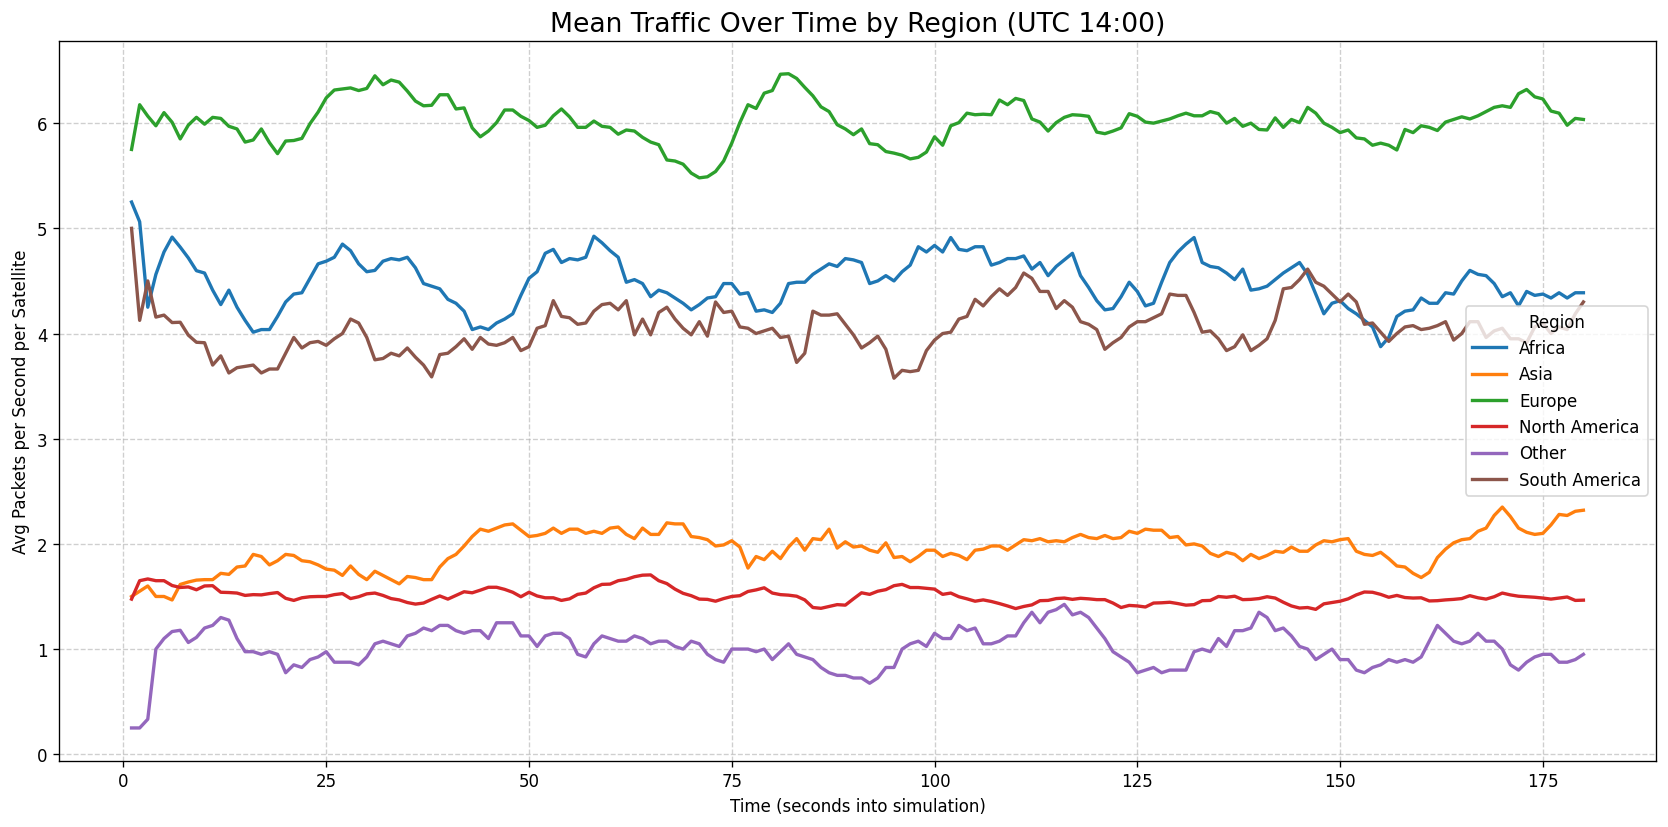

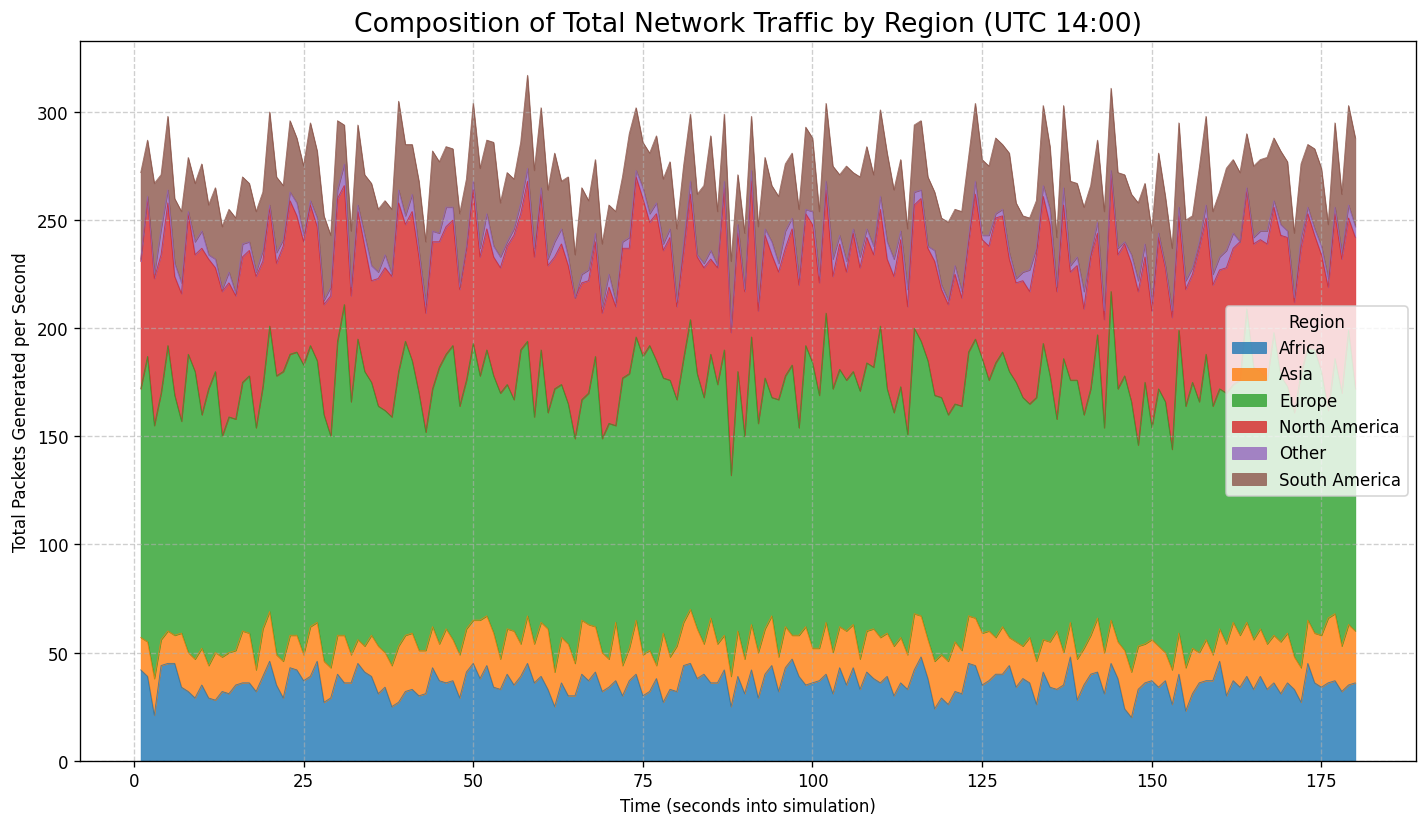


### Phase 5 — Queue simulation (normal load)

FIFO queue dynamics per node over the simulation horizon. Queue lengths stay manageable under normal load — the system is designed to stress-test under peak conditions in Phase 7.

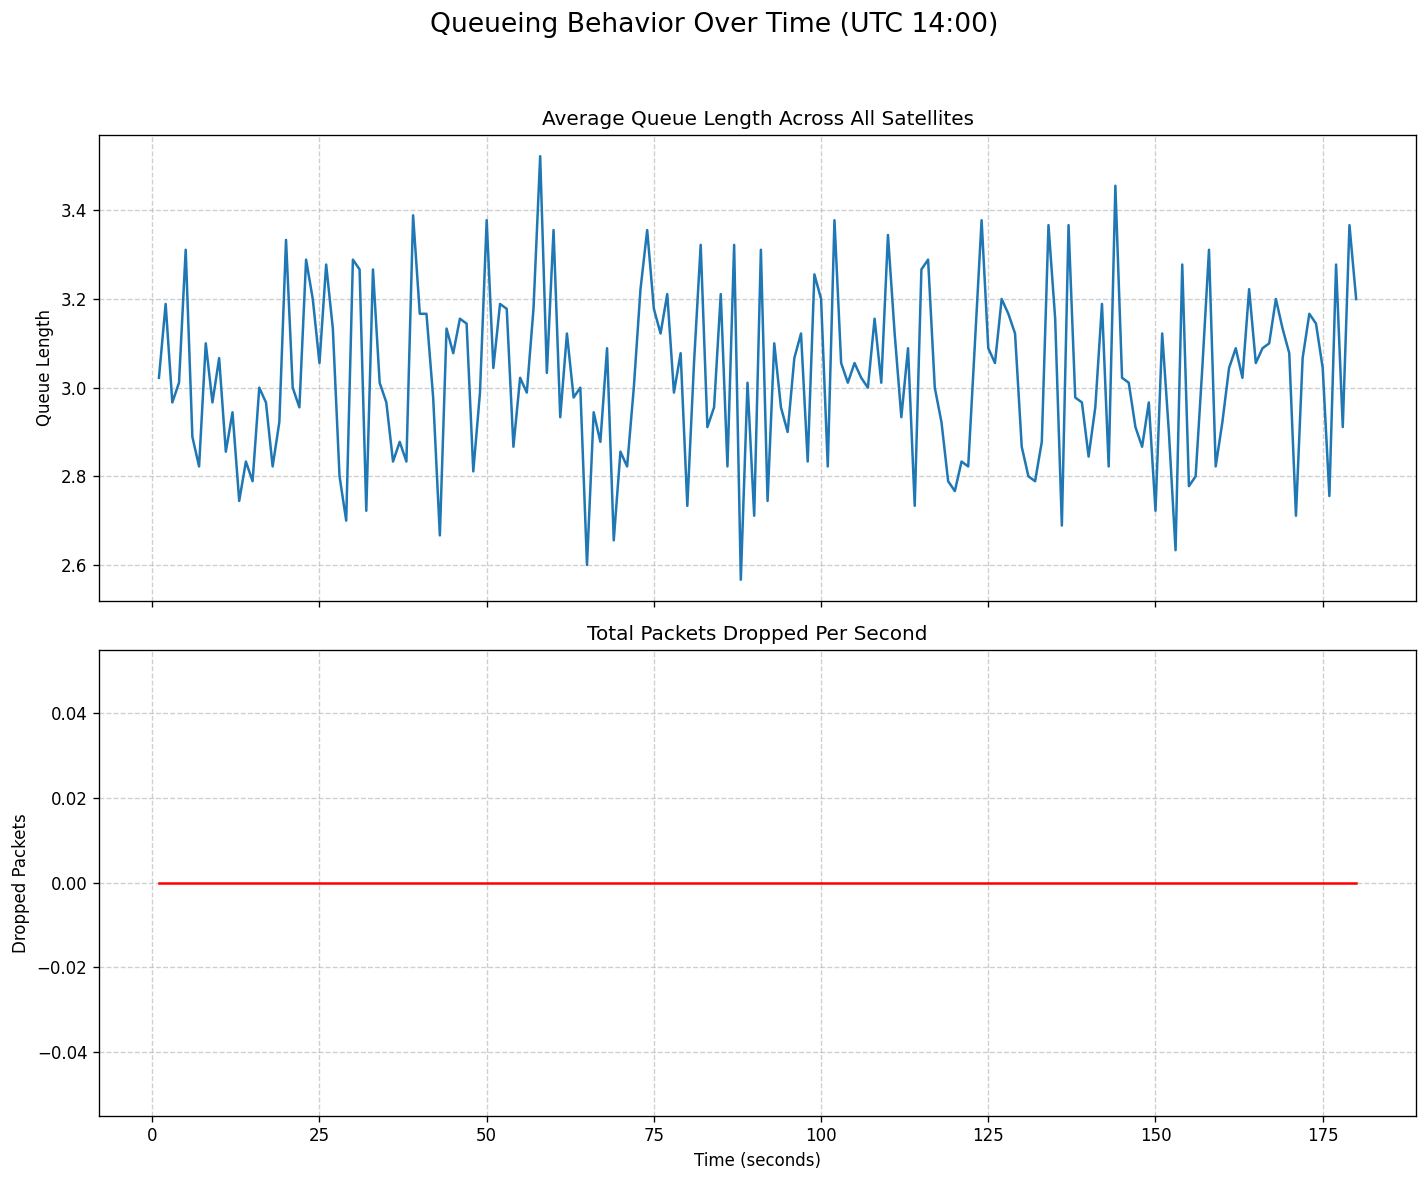


### Phase 6 — Congestion-delay relationship

The key ML insight: traffic generation rate correlates with queue buildup at ρ = 0.99. This makes the neighbor queue proxy (Q(t)/µ) the most informative feature in the model.

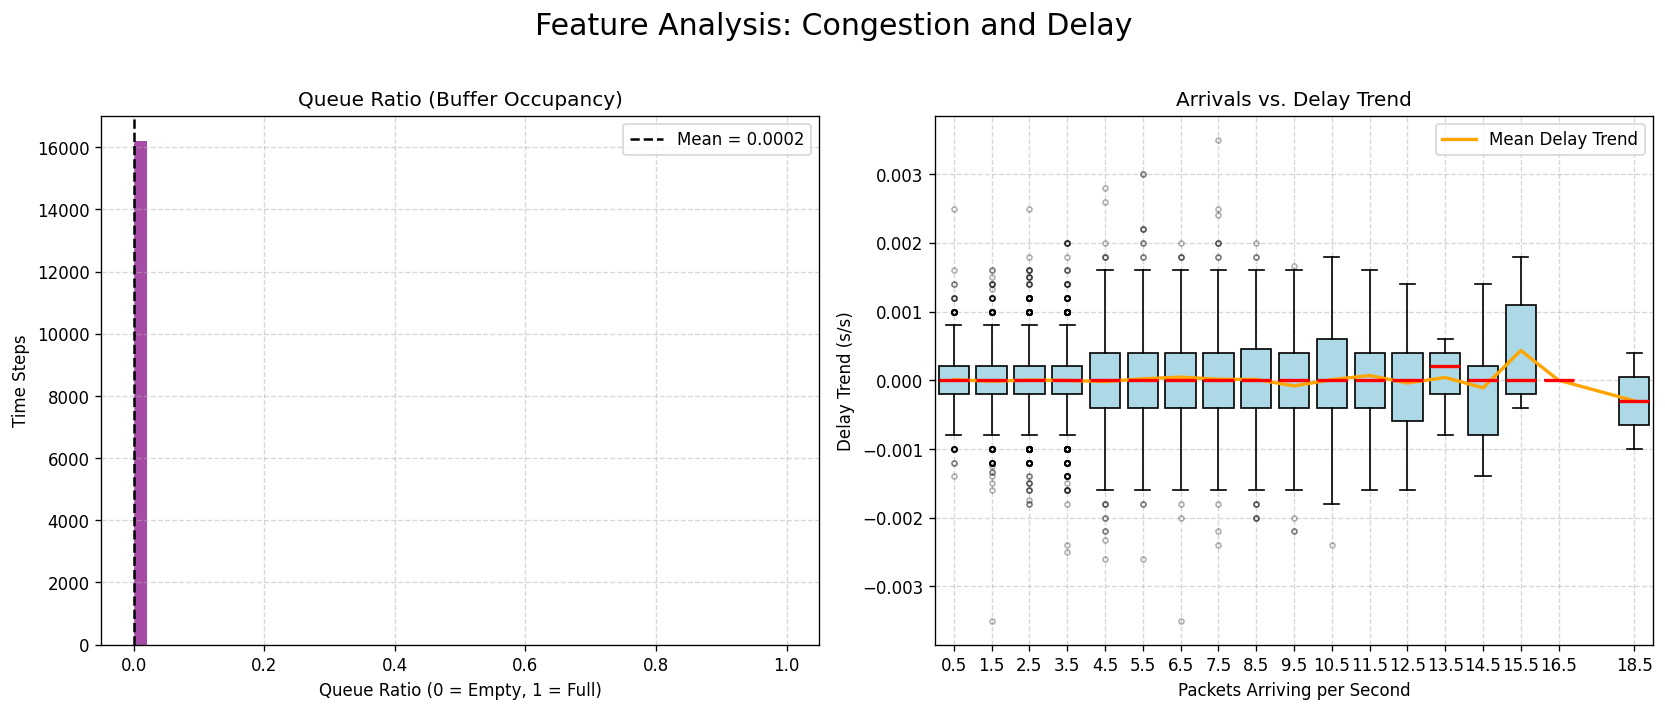


### Phase 7 — Queue simulation (stress load)

Under European-peak stress (λ_EU ≈ 50 pkt/s, service rate µ = 30 pkt/s), queues overflow in the congested corridor. DistanceOnly keeps routing into these saturated paths.

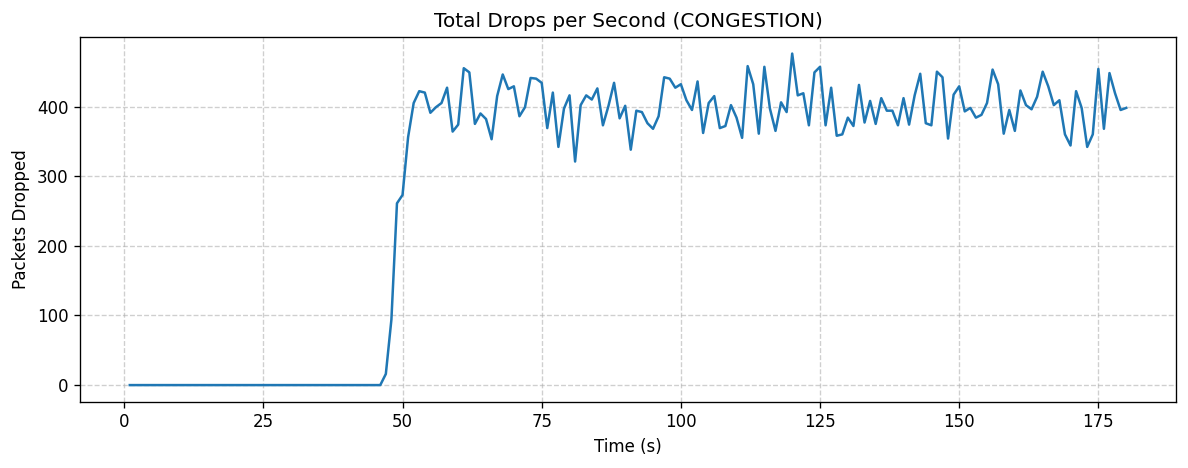


### Phase 9 — Network KPIs: delay, drop rate, throughput

Three-way comparison on the same (t, s, d) pairs. DelayAware dominates on all metrics. The ML-Agent tracks the oracle closely using only near-local features.

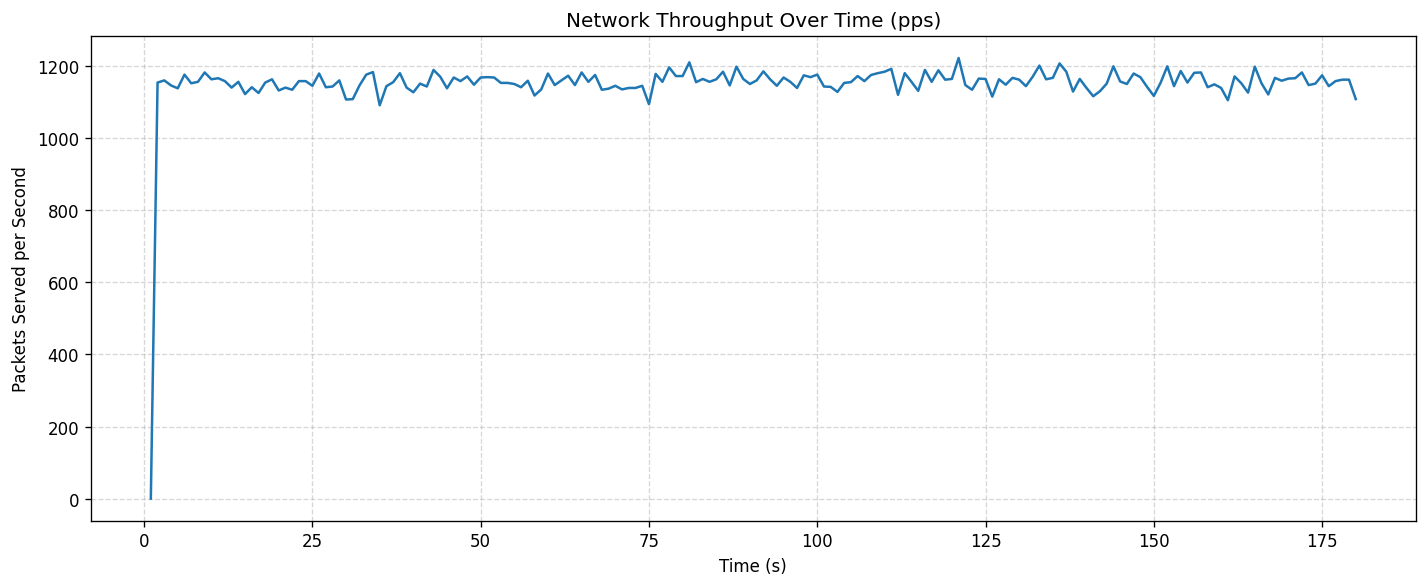

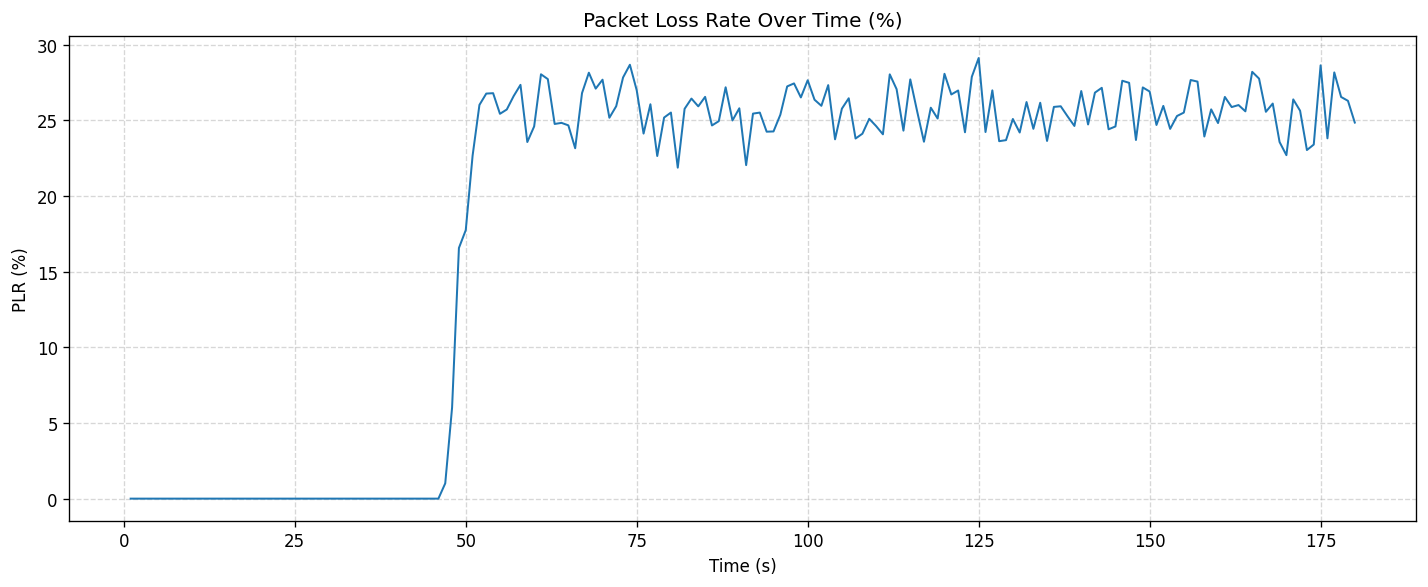

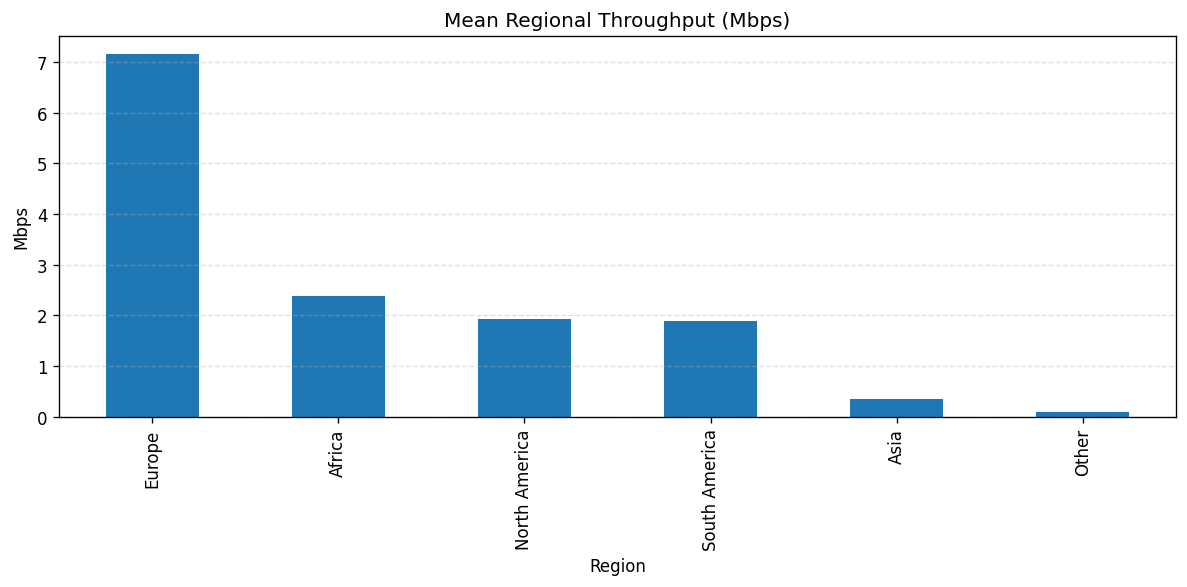


### Phase 11 — Final performance comparison

ML-Agent achieves median end-to-end delay of 1.26 s vs oracle's 1.23 s and baseline's 8.09 s. Path drop rate: 0% for both ML-Agent and DelayAware, ~6.95% for DistanceOnly.

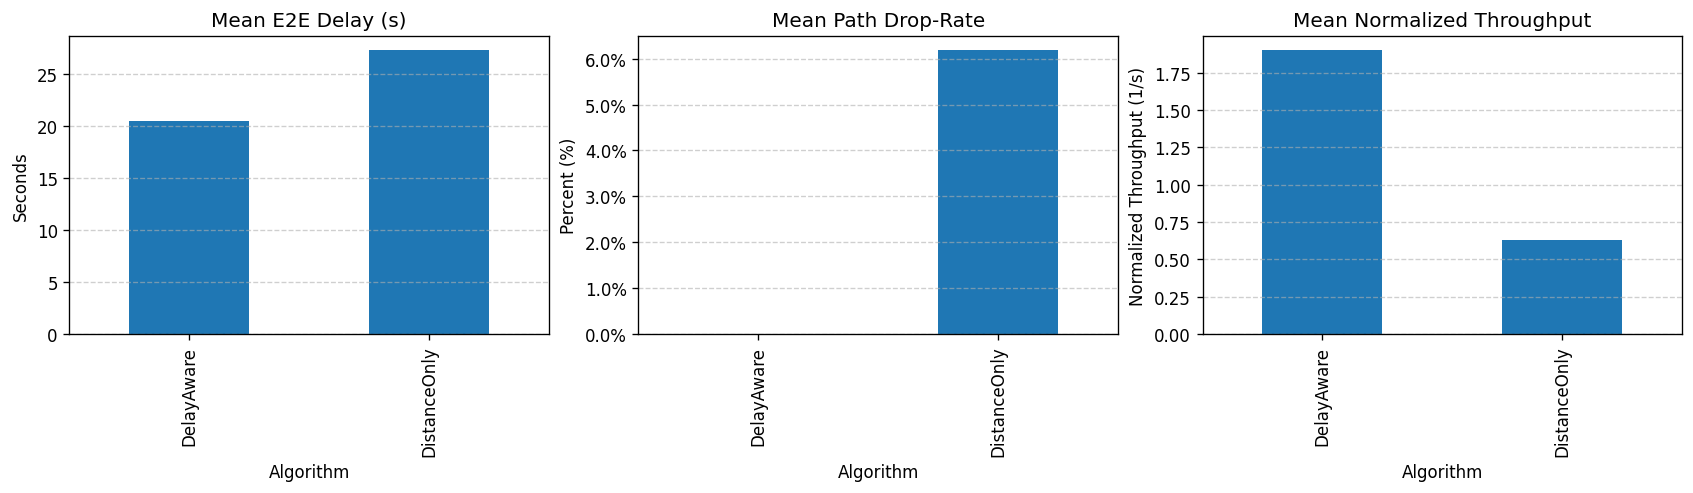


### Phase 11 — Feature importance & diagnostics

Ablation hierarchy: neighbor queue proxy >> congestion flag > geometric progress > propagation alone. Y-randomization drops Group Top-1 from 0.81 to 0.16 (Wilcoxon p=0.002, Cliff's δ=1.0).

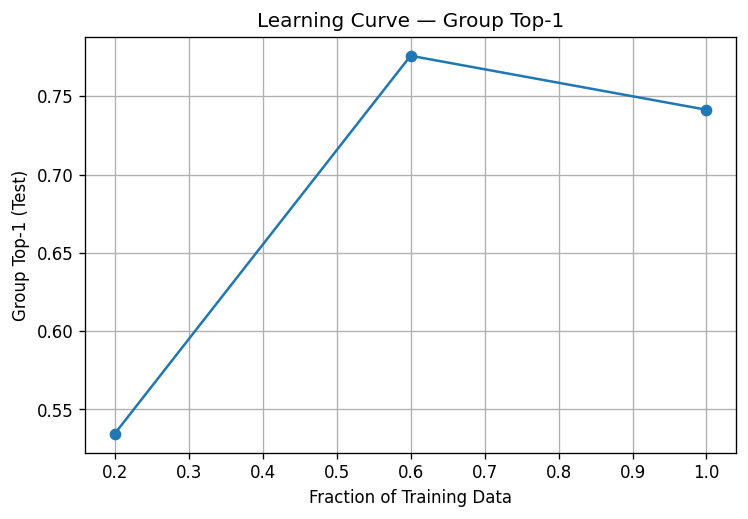

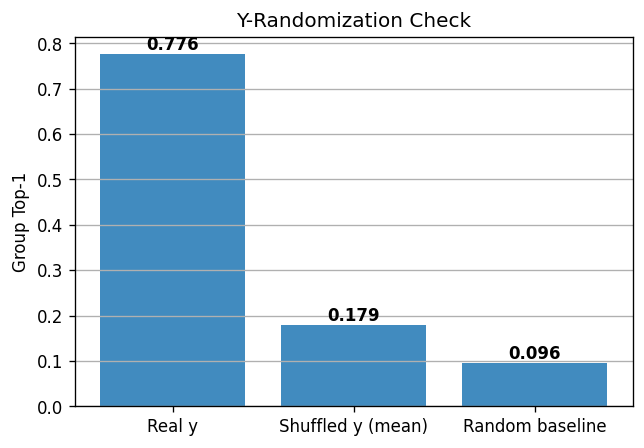


## Results summary

| Metric | ML-Agent | Oracle (DelayAware) | Baseline (DistanceOnly) |
|---|---|---|---|
| Median E2E delay | **1.26 s** | 1.23 s | 8.09 s |
| Path drop rate | **0%** | 0% | ~6.95% |
| Group Top-1 (in-sample) | **0.809 ± 0.041** | — | — |
| Group Top-1 (held-out time) | 0.406 ± 0.008 | — | — |
| Y-randomization control | 0.164 ± 0.072 | — | — |

The ML-Agent recovers ~99.7% of the oracle's delay improvement over the baseline — using only the source's own queue, one-hop neighbor states, and destination geodesic position. No global state exchange at runtime.

---

## Want the full code?

Open a [GitHub issue](https://github.com/Nazanina67/leo-satellite-routing-ml/issues) or reach out on [LinkedIn](https://linkedin.com/in/nazanin-ansaripour).
